
[Tahap 1] Memuat data dari 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL.xlsx' (Sheet: 'Series_Formatted_Data')...
  Data berhasil dimuat. Total baris: 72480

[Tahap 2] Pra-pemrosesan Kolom Waktu 'Time' dan Pengurutan...
  Mengurutkan data berdasarkan: ['Time', 'Longitude', 'Latitude']

[Tahap 3] Imputasi PCI Serving Cell ('NR_UE_PCI_0')...
  Imputasi 'NR_UE_PCI_0' selesai. NaN: 70009 -> 0

[Tahap 4] Imputasi PCI Sel Tetangga (Pattern: NR_UE_Nbr_PCI_{})...
  Memproses 'NR_UE_Nbr_PCI_0'...
      - Dikosongkan 192 nilai karena sama dengan PCI serving.
    - NaN final di 'NR_UE_Nbr_PCI_0': 43050 (Terisi dari ffill/bfill: 28016)
  Memproses 'NR_UE_Nbr_PCI_1'...
      - Dikosongkan 26 nilai karena sama dengan PCI serving.
    - NaN final di 'NR_UE_Nbr_PCI_1': 61961 (Terisi dari ffill/bfill: 10015)
  Memproses 'NR_UE_Nbr_PCI_2'...
      - Dikosongkan 18 nilai karena sama dengan PCI serving.
    - NaN final di 'NR_UE_Nbr_PCI_2': 69835 (Terisi dari ffill/bfill: 2518)
  Memproses

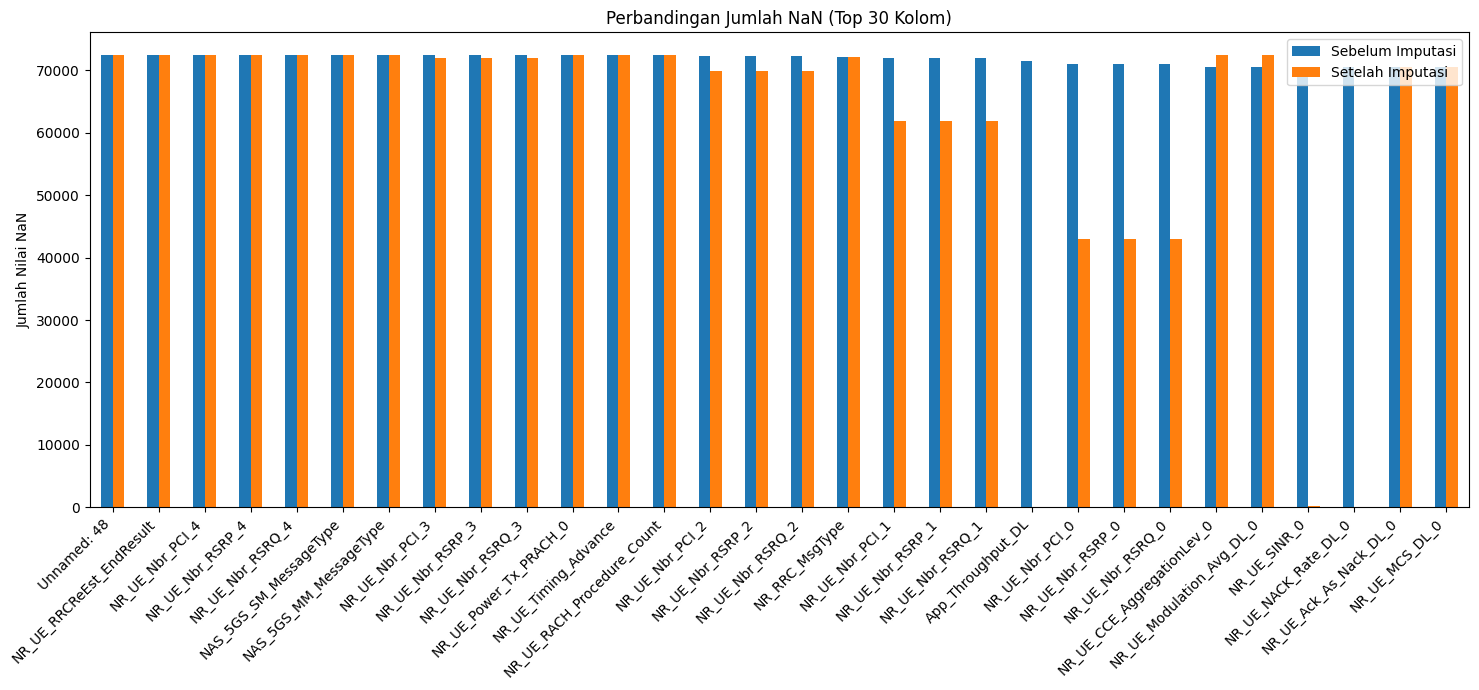


Data yang sudah diolah sepenuhnya disimpan ke '5G_DL_fully_imputed_vFinal.xlsx'

## Total Waktu Eksekusi Skrip: 47.28 menit ##


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder # RobustScaler juga bisa jadi pilihan
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns # Untuk visualisasi yang lebih baik
import os
import time
import warnings

# Menonaktifkan beberapa jenis peringatan
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
pd.options.mode.chained_assignment = None # Hati-hati saat menggunakan ini

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #
FILE_EXCEL = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/5G_DL.xlsx' # Ganti dengan path file Anda
SHEET_NAME = 'Series_Formatted_Data' # Sesuaikan jika perlu
OUTPUT_FILE_PROCESSED = '5G_DL_fully_imputed_vFinal.xlsx'

# --- Kolom Kunci ---
COL_TIME = 'Time'
COL_LON = 'Longitude'
COL_LAT = 'Latitude'
COL_TECH_MODE = 'Technology_Mode' # Fitur kategorikal dasar

# --- Kolom Serving Cell ---
COL_SERVING_PCI = 'NR_UE_PCI_0'
COLS_SERVING_SIGNAL_PRIMARY = ['NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0']
# Tambahkan parameter serving cell lain yang ingin diimputasi dengan RF
COLS_SERVING_SIGNAL_SECONDARY = [
    'NR_UE_Pathloss_DL_0',
    'NR_UE_Throughput_PDCP_DL',
    'App_Throughput_DL',
    'NR_UE_CCE_AggregationLev_0',
    'NR_UE_Modulation_Avg_DL_0', # Jika numerik hasil encode, jika string perlu dihandle
    'NR_UE_RI_DL_0',
    'NR_UE_Power_Tx_PUSCH_0',
    'NR_UE_NACK_Rate_UL_0',
    'NR_UE_BLER_DL_0',
    'NR_UE_NACK_Rate_DL_0',
    # Tambahkan parameter serving cell lain yang butuh imputasi
]

# --- Kolom Neighbor Cell ---
NUM_NEIGHBOR_CELLS = 5 # Jumlah stream neighbor (0-4)
COLS_NBR_PCI_PATTERN = 'NR_UE_Nbr_PCI_{}'
COLS_NBR_RSRP_PATTERN = 'NR_UE_Nbr_RSRP_{}'
COLS_NBR_RSRQ_PATTERN = 'NR_UE_Nbr_RSRQ_{}'

# --- Parameter Imputasi PCI Neighbor ---
MAX_FILL_LIMIT_NBR_PCI = 10 # Seberapa jauh ffill/bfill untuk PCI neighbor
MIN_NBR_PCI_PERSISTENCE = 3 # Jumlah baris minimum PCI neighbor harus persisten agar dianggap valid

# --- Parameter Model Regresi untuk Imputasi ---
# Fitur dasar yang akan digunakan untuk melatih model imputasi RandomForest
# Ini akan diperluas dengan sinyal lain yang sudah diimputasi
BASE_NUMERICAL_FEATURES_FOR_IMPUTATION = [COL_LON, COL_LAT, 'Time_Numeric'] # Time_Numeric akan dibuat
BASE_CATEGORICAL_FEATURES_FOR_IMPUTATION = [COL_TECH_MODE] # Jika ada

# --- ------------------------------------------------------------------ --- #
# ---                      AKHIR KONFIGURASI UTAMA                       --- #
# --- ------------------------------------------------------------------ --- #

def print_nan_summary(df, title="Ringkasan NaN"):
    """Mencetak ringkasan NaN untuk kolom-kolom penting."""
    print(f"\n## {title} ##")
    nan_counts = df.isnull().sum()
    nan_percent = (df.isnull().sum() / len(df)) * 100
    summary_df = pd.DataFrame({'NaN Count': nan_counts, 'NaN Percent': nan_percent})
    # Tampilkan hanya kolom yang memiliki NaN atau kolom-kolom utama
    cols_of_interest = [COL_TIME, COL_SERVING_PCI] + COLS_SERVING_SIGNAL_PRIMARY + COLS_SERVING_SIGNAL_SECONDARY
    for i in range(NUM_NEIGHBOR_CELLS):
        cols_of_interest.append(COLS_NBR_PCI_PATTERN.format(i))
        cols_of_interest.append(COLS_NBR_RSRP_PATTERN.format(i))
        cols_of_interest.append(COLS_NBR_RSRQ_PATTERN.format(i))
    
    # Filter agar hanya menampilkan kolom yang ada di DataFrame dan menarik
    cols_to_show_summary = [col for col in cols_of_interest if col in df.columns]
    if not cols_to_show_summary: # Jika tidak ada kolom menarik, tampilkan semua yg ada NaN
        cols_to_show_summary = summary_df[summary_df['NaN Count'] > 0].index.tolist()
        if not cols_to_show_summary and not summary_df.empty: # Jika tidak ada NaN sama sekali
             cols_to_show_summary = df.columns.tolist()


    if cols_to_show_summary:
        print(summary_df.loc[summary_df.index.isin(cols_to_show_summary)].sort_values(by='NaN Count', ascending=False))
    else:
        print("Tidak ada kolom yang relevan untuk ditampilkan dalam ringkasan NaN atau DataFrame kosong.")
    print("-" * 50)

def plot_nan_distribution_comparison(df_before, df_after, title_before="Sebelum Imputasi", title_after="Setelah Imputasi", N=20):
    """Membuat plot perbandingan distribusi NaN untuk N kolom teratas."""
    nan_before_sum = df_before.isnull().sum()
    nan_after_sum = df_after.isnull().sum()

    # Ambil N kolom dengan NaN terbanyak SEBELUM imputasi
    top_n_cols_before = nan_before_sum.nlargest(N).index.tolist()
    
    # Filter hanya untuk kolom yang ada di kedua DataFrame (jika ada perubahan kolom)
    # dan ada di top_n_cols_before
    cols_to_plot = [col for col in top_n_cols_before if col in df_before.columns and col in df_after.columns]
    
    if not cols_to_plot:
        print("Tidak ada kolom yang cocok untuk perbandingan distribusi NaN.")
        return

    nan_comparison = pd.DataFrame({
        title_before: nan_before_sum.loc[cols_to_plot],
        title_after: nan_after_sum.loc[cols_to_plot]
    }).sort_values(by=title_before, ascending=False)

    if nan_comparison.empty:
        print("Tidak ada data untuk plot perbandingan NaN.")
        return

    nan_comparison.plot(kind='bar', figsize=(15, 7))
    plt.title(f'Perbandingan Jumlah NaN (Top {len(cols_to_plot)} Kolom)')
    plt.ylabel('Jumlah Nilai NaN')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def load_and_prepare_initial_df(file_path, sheet):
    print(f"\n[Tahap 1] Memuat data dari '{file_path}' (Sheet: '{sheet}')...")
    try:
        df_loaded = pd.read_excel(file_path, sheet_name=sheet)
        print(f"  Data berhasil dimuat. Total baris: {len(df_loaded)}")
        df_loaded.columns = df_loaded.columns.str.strip() # Bersihkan spasi nama kolom
        return df_loaded
    except FileNotFoundError: print(f"Error: File '{file_path}' tidak ditemukan."); exit()
    except Exception as e: print(f"Error membaca file Excel: {e}"); exit()

def preprocess_time_column(df_input, time_col, lon_col, lat_col):
    print(f"\n[Tahap 2] Pra-pemrosesan Kolom Waktu '{time_col}' dan Pengurutan...")
    df_processed = df_input.copy()
    if time_col in df_processed.columns:
        df_processed[time_col] = pd.to_datetime(df_processed[time_col], errors='coerce')
        initial_nat = df_processed[time_col].isna().sum()
        if initial_nat > 0:
            print(f"  - Mengisi {initial_nat} NaT di '{time_col}' (interpolasi, ffill, bfill).")
            df_processed[time_col] = df_processed[time_col].interpolate(method='time', limit_direction='both', limit_area='inside')
            df_processed[time_col].fillna(method='ffill', inplace=True)
            df_processed[time_col].fillna(method='bfill', inplace=True)
            if df_processed[time_col].isna().any(): print(f"  - Peringatan: '{time_col}' masih ada NaT.")
    else: print(f"  - Peringatan: Kolom '{time_col}' tidak ada.")

    if time_col in df_processed.columns and df_processed[time_col].notna().all():
        df_processed['Time_Numeric'] = df_processed[time_col].apply(lambda x: x.timestamp())
    elif time_col in df_processed.columns:
        print(f"  - Peringatan: Mengisi NaT di '{time_col}' sebelum membuat Time_Numeric.")
        df_processed[time_col].fillna(method='ffill', inplace=True) # Coba isi lagi
        df_processed[time_col].fillna(method='bfill', inplace=True)
        df_processed['Time_Numeric'] = df_processed[time_col].apply(lambda x: x.timestamp() if pd.notna(x) else np.nan)
        if df_processed['Time_Numeric'].isna().any():
             print(f"  - Menginterpolasi Time_Numeric.")
             df_processed['Time_Numeric'].interpolate(method='linear', limit_direction='both', inplace=True)
             if df_processed['Time_Numeric'].isna().any(): # Jika masih ada NaN (misal semua NaT)
                  df_processed['Time_Numeric'].fillna(0, inplace=True) # Fallback
                  print(f"  - Time_Numeric diisi 0 untuk sisa NaN.")

    else: df_processed['Time_Numeric'] = 0.0 # Atau np.nan jika Time tidak ada

    sort_cols = [col for col in [time_col, lon_col, lat_col] if col in df_processed.columns]
    if sort_cols:
        print(f"  Mengurutkan data berdasarkan: {sort_cols}")
        df_processed.sort_values(by=sort_cols, na_position='last', inplace=True)
    df_processed.reset_index(drop=True, inplace=True)
    return df_processed

def impute_serving_pci(df_input, pci_col):
    print(f"\n[Tahap 3] Imputasi PCI Serving Cell ('{pci_col}')...")
    df_imputed = df_input.copy()
    if pci_col not in df_imputed.columns:
        print(f"  Peringatan: Kolom '{pci_col}' tidak ada. Dilewati."); return df_imputed
    
    nan_before = df_imputed[pci_col].isnull().sum()
    if nan_before == 0: print(f"  Tidak ada NaN di '{pci_col}'."); return df_imputed

    # Logika transisi (diperbaiki untuk iterasi yang aman)
    df_imputed[pci_col] = pd.to_numeric(df_imputed[pci_col], errors='coerce') # Pastikan numerik
    pci_nan_indices = df_imputed[df_imputed[pci_col].isna()].index.tolist()
    processed_indices_set = set()
    
    idx_ptr = 0
    while idx_ptr < len(pci_nan_indices):
        current_original_idx = pci_nan_indices[idx_ptr]
        if current_original_idx in processed_indices_set:
            idx_ptr += 1
            continue

        # Cari PCI sebelum dan sesudah dari DataFrame yang mungkin sudah terupdate
        pci_before_series = df_imputed.loc[:current_original_idx-1, pci_col].dropna()
        pci_after_series = df_imputed.loc[current_original_idx+1:, pci_col].dropna()
        pci_before = pci_before_series.iloc[-1] if not pci_before_series.empty else np.nan
        pci_after = pci_after_series.iloc[0] if not pci_after_series.empty else np.nan

        if pd.notna(pci_before) and pd.notna(pci_after):
            if pci_before == pci_after:
                df_imputed.loc[current_original_idx, pci_col] = pci_before
                processed_indices_set.add(current_original_idx)
            else: # Transisi
                start_nan_block_idx = current_original_idx
                end_nan_block_idx = current_original_idx
                while end_nan_block_idx + 1 < len(df_imputed) and pd.isna(df_imputed.loc[end_nan_block_idx + 1, pci_col]):
                    end_nan_block_idx += 1
                
                nan_block_indices = df_imputed.loc[start_nan_block_idx : end_nan_block_idx][df_imputed[pci_col].isnull()].index
                nan_block_length = len(nan_block_indices)

                if nan_block_length > 0:
                    num_for_before = (nan_block_length + 1) // 2
                    df_imputed.loc[nan_block_indices[:num_for_before], pci_col] = pci_before
                    df_imputed.loc[nan_block_indices[num_for_before:], pci_col] = pci_after
                    processed_indices_set.update(nan_block_indices)
        elif pd.notna(pci_before):
            df_imputed.loc[current_original_idx, pci_col] = pci_before
            processed_indices_set.add(current_original_idx)
        elif pd.notna(pci_after):
            df_imputed.loc[current_original_idx, pci_col] = pci_after
            processed_indices_set.add(current_original_idx)
        idx_ptr +=1 # Pindah ke NaN berikutnya yang belum diproses

    if df_imputed[pci_col].isna().any():
        print(f"  - Mengisi sisa NaN di '{pci_col}' dengan modus global.")
        if not df_imputed[pci_col].dropna().empty:
            df_imputed[pci_col].fillna(df_imputed[pci_col].mode()[0], inplace=True)
        else: df_imputed[pci_col].fillna(-1, inplace=True) # Fallback jika semua NaN
    
    print(f"  Imputasi '{pci_col}' selesai. NaN: {nan_before} -> {df_imputed[pci_col].isnull().sum()}")
    return df_imputed

def impute_neighbor_pci(df_input, nbr_pci_cols_pattern, serving_pci_col, num_nbrs, ffill_limit, bfill_limit, min_persistence):
    print(f"\n[Tahap 4] Imputasi PCI Sel Tetangga (Pattern: {nbr_pci_cols_pattern})...")
    df_imputed = df_input.copy()
    for i in range(num_nbrs):
        col_pci_nbr_item = nbr_pci_cols_pattern.format(i)
        if col_pci_nbr_item not in df_imputed.columns:
            print(f"  - Peringatan: Kolom '{col_pci_nbr_item}' tidak ada. Dilewati."); continue
        
        print(f"  Memproses '{col_pci_nbr_item}'...")
        nan_awal = df_imputed[col_pci_nbr_item].isnull().sum()
        if nan_awal == len(df_imputed): print(f"    - Kolom seluruhnya NaN."); continue
        if nan_awal == 0: print(f"    - Tidak ada NaN."); continue

        df_imputed[col_pci_nbr_item] = pd.to_numeric(df_imputed[col_pci_nbr_item], errors='coerce')
        original_nan_mask_nbr = df_imputed[col_pci_nbr_item].isnull()

        df_imputed[col_pci_nbr_item].fillna(method='ffill', limit=ffill_limit, inplace=True)
        df_imputed[col_pci_nbr_item].fillna(method='bfill', limit=bfill_limit, inplace=True)
        
        if serving_pci_col in df_imputed.columns and df_imputed[serving_pci_col].notna().any():
            temp_nbr_numeric = pd.to_numeric(df_imputed[col_pci_nbr_item], errors='coerce')
            temp_serving_numeric = pd.to_numeric(df_imputed[serving_pci_col], errors='coerce')
            conflict = (temp_nbr_numeric == temp_serving_numeric) & temp_nbr_numeric.notna()
            if conflict.sum() > 0:
                df_imputed.loc[conflict, col_pci_nbr_item] = np.nan
                print(f"      - Dikosongkan {conflict.sum()} nilai karena sama dengan PCI serving.")
        
        if min_persistence > 0 and df_imputed[col_pci_nbr_item].notna().any():
            current_non_nan_for_persist = df_imputed[col_pci_nbr_item].notna()
            if current_non_nan_for_persist.any():
                df_temp_persist = df_imputed.loc[current_non_nan_for_persist].copy()
                df_temp_persist['block_id'] = (df_temp_persist[col_pci_nbr_item].diff() != 0).cumsum()
                block_sizes_persist = df_temp_persist.groupby('block_id')[col_pci_nbr_item].transform('size')
                indices_to_revert_persist = df_temp_persist[(block_sizes_persist < min_persistence) & (original_nan_mask_nbr.loc[df_temp_persist.index])].index
                if not indices_to_revert_persist.empty:
                    df_imputed.loc[indices_to_revert_persist, col_pci_nbr_item] = np.nan
                    print(f"      - Dikembalikan {len(indices_to_revert_persist)} nilai karena gagal validasi persistensi.")
        
        print(f"    - NaN final di '{col_pci_nbr_item}': {df_imputed[col_pci_nbr_item].isnull().sum()} (Terisi dari ffill/bfill: {nan_awal - df_imputed[col_pci_nbr_item].isnull().sum()})")
    return df_imputed

def get_feature_preprocessor(numerical_features, categorical_features, df_reference_for_fit=None):
    """Membuat objek ColumnTransformer untuk pra-pemrosesan fitur."""
    valid_num_features = [f for f in numerical_features if f in df_reference_for_fit.columns] if df_reference_for_fit is not None else numerical_features
    valid_cat_features = [f for f in categorical_features if f in df_reference_for_fit.columns] if df_reference_for_fit is not None else categorical_features

    transformers = []
    if valid_num_features:
        numeric_pipeline = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()) # Atau RobustScaler
        ])
        transformers.append(('num', numeric_pipeline, valid_num_features))
    
    if valid_cat_features:
        categorical_pipeline = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')), # Atau isi dengan 'UNKNOWN'
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])
        transformers.append(('cat', categorical_pipeline, valid_cat_features))

    if not transformers: return None
    return ColumnTransformer(transformers=transformers, remainder='drop')


def impute_signal_with_rf(df_input, target_signal_col, group_by_col, 
                          base_num_features, base_cat_features, 
                          additional_context_features=None, preprocessor_to_use=None):
    """Imputasi kolom sinyal target menggunakan RF per grup."""
    print(f"\n[Tahap Imputasi Sinyal] Target: '{target_signal_col}', Grup: '{group_by_col}'")
    df_processed = df_input.copy()
    if target_signal_col not in df_processed.columns:
        print(f"  Peringatan: Kolom target '{target_signal_col}' tidak ada. Dilewati."); return df_processed
    if group_by_col not in df_processed.columns or df_processed[group_by_col].isnull().all():
        print(f"  Peringatan: Kolom grup '{group_by_col}' tidak ada atau semua NaN. Imputasi global mungkin kurang akurat atau gagal. Dilewati."); return df_processed

    nan_before_imputation = df_processed[target_signal_col].isnull().sum()
    if nan_before_imputation == 0:
        print(f"  Tidak ada NaN di '{target_signal_col}'. Tidak ada imputasi RF."); return df_processed

    print(f"  Total NaN awal di '{target_signal_col}': {nan_before_imputation}")
    df_processed[target_signal_col] = pd.to_numeric(df_processed[target_signal_col], errors='coerce')

    # Definisikan fitur yang akan digunakan untuk model imputasi ini
    current_imputation_features = [f for f in base_num_features + base_cat_features if f in df_processed.columns and f != target_signal_col]
    if additional_context_features:
        current_imputation_features.extend([f for f in additional_context_features if f in df_processed.columns and f != target_signal_col])
    current_imputation_features = sorted(list(set(current_imputation_features))) # Unik dan urut

    if not current_imputation_features:
        print(f"  Peringatan: Tidak ada fitur valid untuk imputasi '{target_signal_col}'. Mencoba interpolasi & median grup.");
        # Lakukan interpolasi dan median fill sebagai fallback jika tidak ada fitur
        if df_processed[target_signal_col].isnull().any():
            df_processed[target_signal_col] = df_processed.groupby(group_by_col)[target_signal_col].transform(
                lambda x: x.interpolate(method='linear', limit_direction='both', limit_area='inside')
            )
            df_processed[target_signal_col] = df_processed.groupby(group_by_col)[target_signal_col].transform(
                lambda x: x.fillna(x.median()) if x.notna().any() else x # Median grup
            )
            df_processed[target_signal_col].fillna(df_processed[target_signal_col].median(), inplace=True) # Median global
        print(f"  NaN final di '{target_signal_col}': {df_processed[target_signal_col].isnull().sum()}"); return df_processed

    # Persiapkan preprocessor jika belum ada
    if preprocessor_to_use is None:
        # Buat preprocessor HANYA dengan fitur yang ada di current_imputation_features
        num_feats_for_current_model = [f for f in base_num_features + (additional_context_features if additional_context_features else []) if f in current_imputation_features]
        cat_feats_for_current_model = [f for f in base_cat_features if f in current_imputation_features]
        preprocessor_to_use = get_feature_preprocessor(num_feats_for_current_model, cat_feats_for_current_model, df_processed)

    if preprocessor_to_use is None:
        print(f"  Peringatan: Gagal membuat preprocessor untuk '{target_signal_col}'. Mencoba interpolasi & median grup.");
        # Fallback (sama seperti di atas)
        if df_processed[target_signal_col].isnull().any():
            df_processed[target_signal_col] = df_processed.groupby(group_by_col)[target_signal_col].transform(
                lambda x: x.interpolate(method='linear', limit_direction='both', limit_area='inside')
            )
            df_processed[target_signal_col] = df_processed.groupby(group_by_col)[target_signal_col].transform(
                lambda x: x.fillna(x.median()) if x.notna().any() else x
            )
            df_processed[target_signal_col].fillna(df_processed[target_signal_col].median(), inplace=True)
        print(f"  NaN final di '{target_signal_col}': {df_processed[target_signal_col].isnull().sum()}"); return df_processed

    # Buat kolom ID grup sementara untuk iterasi
    temp_group_id_col = f"{group_by_col}_temp_groupid_for_{target_signal_col.replace('[','').replace(']','').replace('_','').replace('.','')}" # Nama unik
    df_processed[temp_group_id_col] = (df_processed[group_by_col].diff() != 0).cumsum()
    unique_groups_for_target = df_processed[temp_group_id_col].unique()
    
    imputed_group_dfs = []

    for group_val_id in unique_groups_for_target:
        df_current_group = df_processed[df_processed[temp_group_id_col] == group_val_id].copy()
        if df_current_group.empty: continue

        group_identifier_val = df_current_group[group_by_col].iloc[0] # Untuk logging
        
        # 1. Interpolasi Linier dalam grup
        nan_in_group_before_interp = df_current_group[target_signal_col].isnull().sum()
        if nan_in_group_before_interp > 0:
            # Urutkan berdasarkan Time_Numeric dalam grup untuk interpolasi yang benar
            df_current_group.sort_values(by=['Time_Numeric'], inplace=True)
            df_current_group[target_signal_col] = df_current_group[target_signal_col].interpolate(method='linear', limit_direction='both', limit_area='inside')
        
        # 2. RandomForestRegressor jika masih ada NaN
        if df_current_group[target_signal_col].isnull().any():
            df_known = df_current_group[df_current_group[target_signal_col].notna()].copy()
            df_missing = df_current_group[df_current_group[target_signal_col].isna()].copy()
            
            if not df_known.empty and len(df_known) >= 10 and not df_missing.empty:
                # Pastikan fitur untuk model ada di df_known dan df_missing
                valid_feats_in_group = [f for f in current_imputation_features if f in df_known.columns]
                if not valid_feats_in_group:
                    # print(f"    - Grup {group_identifier_val}: Tidak ada fitur valid untuk RF. Menggunakan median grup.")
                    if not df_current_group[target_signal_col].dropna().empty:
                        df_current_group.loc[df_missing.index, target_signal_col] = df_current_group[target_signal_col].dropna().median()
                    imputed_group_dfs.append(df_current_group); continue

                X_train_rf = df_known[valid_feats_in_group]
                y_train_rf = df_known[target_signal_col]
                X_predict_rf = df_missing[valid_feats_in_group]

                try:
                    # Fit preprocessor pada X_train_rf dari grup ini saja
                    # Ini bisa jadi kurang ideal jika grup sangat kecil, preprocessor mungkin lebih baik di-fit global
                    # atau pada data training yang lebih besar. Untuk sekarang, fit per grup.
                    current_preprocessor = get_feature_preprocessor(
                        [f for f in base_num_features + (additional_context_features if additional_context_features else []) if f in valid_feats_in_group],
                        [f for f in base_cat_features if f in valid_feats_in_group],
                        X_train_rf # Fit pada data training grup ini
                    )
                    if current_preprocessor is None: raise ValueError("Preprocessor tidak bisa dibuat untuk grup ini.")

                    X_train_transformed_rf = current_preprocessor.fit_transform(X_train_rf)
                    X_predict_transformed_rf = current_preprocessor.transform(X_predict_rf)

                    model_rf_impute = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10, min_samples_leaf=5)
                    model_rf_impute.fit(X_train_transformed_rf, y_train_rf)
                    predicted_vals_rf = model_rf_impute.predict(X_predict_transformed_rf)
                    df_current_group.loc[df_missing.index, target_signal_col] = predicted_vals_rf
                except Exception as e:
                    print(f"    - Error RF grup {group_identifier_val}, target '{target_signal_col}': {e}. Menggunakan median grup.")
                    if not df_current_group[target_signal_col].dropna().empty:
                         df_current_group.loc[df_missing.index, target_signal_col] = df_current_group[target_signal_col].dropna().median()
            elif not df_missing.empty: # Tidak cukup data train atau tidak ada data train
                if not df_current_group[target_signal_col].dropna().empty:
                    df_current_group.loc[df_missing.index, target_signal_col] = df_current_group[target_signal_col].dropna().median()
        
        imputed_group_dfs.append(df_current_group)

    if imputed_group_dfs:
        df_processed = pd.concat(imputed_group_dfs).sort_index() # Urutkan kembali berdasarkan indeks asli
    
    df_processed.drop(columns=[temp_group_id_col], inplace=True, errors='ignore')
    nan_after_imputation = df_processed[target_signal_col].isnull().sum()
    print(f"  Imputasi '{target_signal_col}' selesai. Total NaN: {nan_before_imputation} -> {nan_after_imputation} (Terisi: {nan_before_imputation - nan_after_imputation})")
    return df_processed


# --- Script Utama ---
if __name__ == "__main__":
    start_total_time = time.time()
    df = load_and_prepare_initial_df(FILE_EXCEL, SHEET_NAME)
    df_before_imputation = df.copy() # Simpan untuk perbandingan NaN
    
    df = preprocess_time_column(df, COL_TIME, COL_LON, COL_LAT)
    df = impute_serving_pci(df, COL_SERVING_PCI)
    df = impute_neighbor_pci(df, COLS_NBR_PCI_PATTERN, COL_SERVING_PCI, NUM_NEIGHBOR_CELLS, 
                             MAX_FILL_LIMIT_NBR_PCI, MAX_FILL_LIMIT_NBR_PCI, MIN_NBR_PCI_PERSISTENCE)
    
    print_nan_summary(df, "Ringkasan NaN SETELAH Imputasi PCI")

    # --- Mendefinisikan Fitur untuk Regresi Sinyal ---
    # Fitur dasar numerik (selalu ada)
    numerical_features_for_model = [COL_LON, COL_LAT]
    if 'Time_Numeric' in df.columns: numerical_features_for_model.append('Time_Numeric')
    
    # Fitur dasar kategorikal (selalu ada)
    categorical_features_for_model = []
    if COL_TECH_MODE in df.columns: categorical_features_for_model.append(COL_TECH_MODE)

    # Fitur KONTEKS TAMBAHAN untuk imputasi sinyal
    # Untuk Serving Signals, PCI Serving adalah group_by_col, jadi tidak perlu di fitur
    # Untuk Neighbor Signals, PCI Serving dan PCI Neighbor (streamnya) adalah group_by_col

    # 1. Imputasi Sinyal Serving Cell
    # Fitur konteks: tidak ada PCI karena sudah jadi grup
    for sig_col_serve in COLS_SERVING_SIGNAL_PRIMARY:
        df = impute_signal_with_rf(df, 
                                   target_signal_col=sig_col_serve, 
                                   group_by_col=COL_SERVING_PCI,
                                   base_num_features=numerical_features_for_model, # Lat, Lon, Time_Num
                                   base_cat_features=categorical_features_for_model, # Tech_Mode
                                   additional_context_features=None) # Tidak ada konteks tambahan untuk RSRP/RSRQ/SINR serving awal
    print_nan_summary(df, f"Ringkasan NaN SETELAH Imputasi Sinyal Serving ({COLS_SERVING_SIGNAL_PRIMARY})")


    # 2. Imputasi Sinyal Neighbor Cell
    # Fitur konteks untuk neighbor: PCI serving, dan sinyal serving yang sudah diimputasi
    context_features_for_nbr = [COL_SERVING_PCI] + COLS_SERVING_SIGNAL_PRIMARY
    # Pastikan fitur konteks ini numerik (PCI serving mungkin perlu di-encode jika belum)
    # Untuk GPR/RF, PCI serving bisa diperlakukan numerik atau di-encode.
    # Kita asumsikan COL_SERVING_PCI sudah numerik (atau akan dihandle SimpleImputer di preprocessor)

    for i in range(NUM_NEIGHBOR_CELLS):
        current_nbr_pci_col = COLS_NBR_PCI_PATTERN.format(i)
        current_nbr_rsrp_col = COLS_NBR_RSRP_PATTERN.format(i)
        current_nbr_rsrq_col = COLS_NBR_RSRQ_PATTERN.format(i)

        if current_nbr_pci_col not in df.columns: continue # Skip jika kolom PCI stream ini tidak ada

        # Imputasi RSRP neighbor
        if current_nbr_rsrp_col in df.columns:
            df = impute_signal_with_rf(df,
                                       target_signal_col=current_nbr_rsrp_col,
                                       group_by_col=current_nbr_pci_col, # Grup berdasarkan PCI neighbor ini
                                       base_num_features=numerical_features_for_model,
                                       base_cat_features=categorical_features_for_model,
                                       additional_context_features=context_features_for_nbr)
        # Imputasi RSRQ neighbor
        if current_nbr_rsrq_col in df.columns:
             df = impute_signal_with_rf(df,
                                       target_signal_col=current_nbr_rsrq_col,
                                       group_by_col=current_nbr_pci_col,
                                       base_num_features=numerical_features_for_model,
                                       base_cat_features=categorical_features_for_model,
                                       additional_context_features=context_features_for_nbr)
    print_nan_summary(df, "Ringkasan NaN SETELAH Imputasi Sinyal Neighbor")


    # 3. Imputasi COLS_SERVING_SIGNAL_SECONDARY (Pathloss, Throughput, dll.)
    # Fitur konteks: PCI serving, dan SEMUA sinyal serving primer yang sudah diimputasi
    context_features_for_secondary = [COL_SERVING_PCI] + COLS_SERVING_SIGNAL_PRIMARY
    
    # Urutan imputasi untuk secondary signals mungkin penting jika ada dependensi
    # Misal, Pathloss dulu, baru Throughput menggunakan Pathloss sbg fitur.
    # Untuk contoh ini, kita imputasi satu per satu.

    # Imputasi Pathloss
    if 'NR_UE_Pathloss_DL_0' in COLS_SERVING_SIGNAL_SECONDARY and 'NR_UE_Pathloss_DL_0' in df.columns:
        df = impute_signal_with_rf(df,
                                   target_signal_col='NR_UE_Pathloss_DL_0',
                                   group_by_col=COL_SERVING_PCI,
                                   base_num_features=numerical_features_for_model,
                                   base_cat_features=categorical_features_for_model,
                                   additional_context_features=context_features_for_secondary)
        # Tambahkan Pathloss ke context_features untuk imputasi berikutnya jika berhasil diimputasi
        if 'NR_UE_Pathloss_DL_0' in df.columns and df['NR_UE_Pathloss_DL_0'].notna().any():
            if 'NR_UE_Pathloss_DL_0' not in context_features_for_secondary: # Hindari duplikasi
                 context_features_for_secondary.append('NR_UE_Pathloss_DL_0')


    # Imputasi Throughput PDCP DL
    if 'NR_UE_Throughput_PDCP_DL' in COLS_SERVING_SIGNAL_SECONDARY and 'NR_UE_Throughput_PDCP_DL' in df.columns:
        df = impute_signal_with_rf(df,
                                   target_signal_col='NR_UE_Throughput_PDCP_DL',
                                   group_by_col=COL_SERVING_PCI,
                                   base_num_features=numerical_features_for_model,
                                   base_cat_features=categorical_features_for_model,
                                   additional_context_features=context_features_for_secondary) # Sekarang Pathloss ada di sini
        if 'NR_UE_Throughput_PDCP_DL' in df.columns and df['NR_UE_Throughput_PDCP_DL'].notna().any():
            if 'NR_UE_Throughput_PDCP_DL' not in context_features_for_secondary:
                 context_features_for_secondary.append('NR_UE_Throughput_PDCP_DL')


    # Imputasi App Throughput DL
    if 'App_Throughput_DL' in COLS_SERVING_SIGNAL_SECONDARY and 'App_Throughput_DL' in df.columns:
        # Aturan khusus: Jika PDCP Throughput = 0 (atau NaN setelah imputasi), App Throughput = 0
        if 'NR_UE_Throughput_PDCP_DL' in df.columns:
            condition_zero_pdcp = (df['NR_UE_Throughput_PDCP_DL'] == 0) | (df['NR_UE_Throughput_PDCP_DL'].isnull())
            df.loc[condition_zero_pdcp & df['App_Throughput_DL'].isnull(), 'App_Throughput_DL'] = 0

        df = impute_signal_with_rf(df,
                                   target_signal_col='App_Throughput_DL',
                                   group_by_col=COL_SERVING_PCI,
                                   base_num_features=numerical_features_for_model,
                                   base_cat_features=categorical_features_for_model,
                                   additional_context_features=context_features_for_secondary) # Sekarang Pathloss & PDCP ada


    # Imputasi fitur sekunder lainnya
    # Anda perlu loop atau memanggil impute_signal_with_rf untuk setiap item di COLS_SERVING_SIGNAL_SECONDARY
    # dengan hati-hati mengatur additional_context_features jika ada dependensi
    remaining_secondary_cols = [
        col for col in COLS_SERVING_SIGNAL_SECONDARY
        if col not in ['NR_UE_Pathloss_DL_0', 'NR_UE_Throughput_PDCP_DL', 'App_Throughput_DL'] and col in df.columns
    ]
    for sec_col in remaining_secondary_cols:
        # Asumsi fitur sekunder ini tidak terlalu bergantung pada fitur sekunder lain yang belum diimputasi
        # Anda mungkin perlu urutan yang lebih spesifik
        df = impute_signal_with_rf(df,
                                   target_signal_col=sec_col,
                                   group_by_col=COL_SERVING_PCI,
                                   base_num_features=numerical_features_for_model,
                                   base_cat_features=categorical_features_for_model,
                                   additional_context_features=context_features_for_secondary)


    print_nan_summary(df, f"Ringkasan NaN SETELAH Imputasi Sinyal Sekunder (Pathloss, Throughput, dll.)")


    # --- Visualisasi Perbandingan NaN ---
    plot_nan_distribution_comparison(df_before_imputation, df, N=30) # Tampilkan 30 kolom teratas

    # --- Simpan Hasil ---
    try:
        output_dir = os.path.dirname(OUTPUT_FILE_PROCESSED)
        if output_dir and not os.path.exists(output_dir): os.makedirs(output_dir)
        df.to_excel(OUTPUT_FILE_PROCESSED, index=False, engine='openpyxl')
        print(f"\nData yang sudah diolah sepenuhnya disimpan ke '{OUTPUT_FILE_PROCESSED}'")
    except Exception as e: print(f"\nError saat menyimpan file: {e}")

    end_total_time = time.time()
    print(f"\n## Total Waktu Eksekusi Skrip: {(end_total_time - start_total_time)/60:.2f} menit ##")